# Decoded Plots

In [22]:
import sys
import importlib
import pandas as pd
from pathlib import Path

repo_src = None
repo_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    if (base / "src" / "plots" / "plot_helpers.py").exists():
        repo_src = base / "src" / "plots"
        repo_root = base
        break
    if (base / "plots" / "plot_helpers.py").exists():
        repo_src = base / "plots"
        repo_root = base.parent
        break
    if (base / "plot_helpers.py").exists():
        repo_src = base
        repo_root = base.parent.parent
        break

if repo_src is None or repo_root is None:
    raise FileNotFoundError("Could not locate plot_helpers.py")

if str(repo_src) not in sys.path:
    sys.path.insert(0, str(repo_src))

import plot_helpers

importlib.reload(plot_helpers)

paths = {
    "bpsk": repo_root / "output" / "260618_decoded_ultimate_bpsk.csv",
    "dpsk": repo_root / "output" / "260619_decoded_ultimate_specific_dpsk.csv",
}

source = pd.read_csv(
    paths["dpsk"],
)


# source = source[source["cycles_per_symbol"] == 7]
def average_results(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby(["frequency", "volume_gain_data", "message"], as_index=False)[
            "error_rate"
        ]
        .mean()
        .assign(msg_len=lambda x: x["message"].str.len())
        .sort_values("msg_len")
        .drop(columns="msg_len")
    )


df_first = source[source["type"] == "compressed"]
df_second = source[source["type"] == "uncompressed"]

df_first_average = average_results(df_first)
df_second_average = average_results(df_second)


# df_second = pd.read_csv(
#     paths["bpsk"],
# )
print(df_first["volume_gain_data"].dtype)

LABEL_FIRST: str = "dpsk with WhatsApp"
LABEL_SECOND: str = "dpsk best scenario"

float64


# Comparison between DBPSK and BPSK
From this comparison we can analyze what actually gets recognized in the file: is the preamble recognized? Is the decoded payload long enough?
These are the possible errors:
* `not-valid-preamble`: the preamble has not been recognized
* `check-error`: safety guards on the waveform properties
* `no-length-in-header`: the header is shorter than 16 bits, which are used to represent the number of bytes of the payload
* `paylod-too-short`: the payload is shorter than the number of bytes that are in the header

If there is no error, the status is `valid-preamble`.

In [23]:
from plot_helpers import print_decode_status, print_error_comparison

print(f"{LABEL_FIRST}:")
print_decode_status(df_first)
print()
print(f"{LABEL_SECOND}:")
print_decode_status(df_second)
print()
print_error_comparison(
    df_first,
    df_second,
    LABEL_FIRST,
    LABEL_SECOND,
)

dpsk with WhatsApp:
valid preambles: 598
not valid: 1
errors: 1
types of error: ['paylod-too-short']

dpsk best scenario:
valid preambles: 600
not valid: 0
errors: 0
types of error: []

Mean error dpsk with WhatsApp: 0.0856
Mean error dpsk best scenario: 0.0011
Variance error dpsk with WhatsApp: 0.031
Variance error dpsk best scenario: 0.0

dpsk with WhatsApp is better than dpsk best scenario: 0, 0.0%
dpsk with WhatsApp is equal to dpsk best scenario: 0, 0.0%
dpsk with WhatsApp is worse than dpsk best scenario: 0, 0.0%
Mean improvement: nan
Improvement variance: nan
Mean worsening: nan
Worsening variance: nan


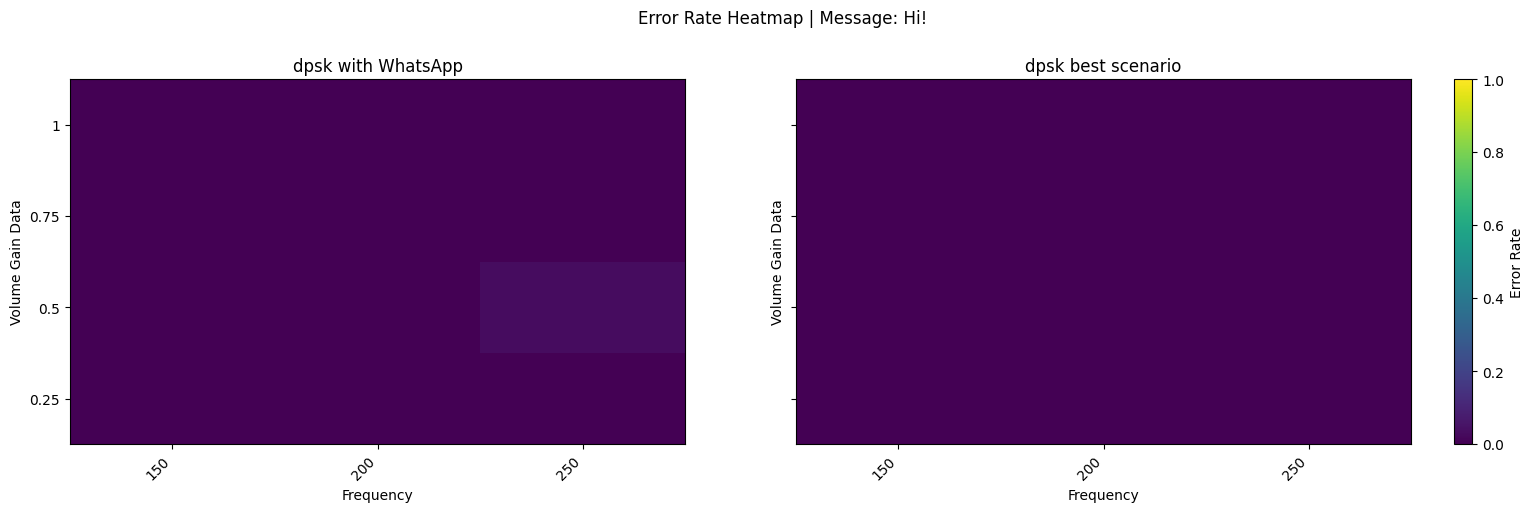

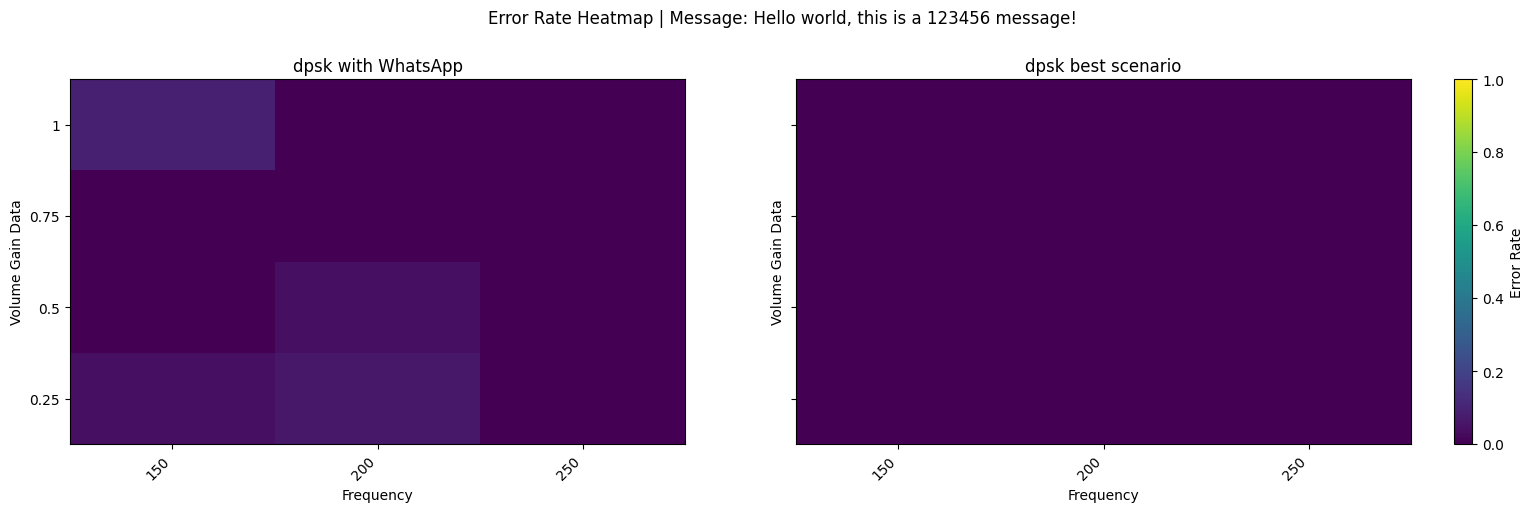

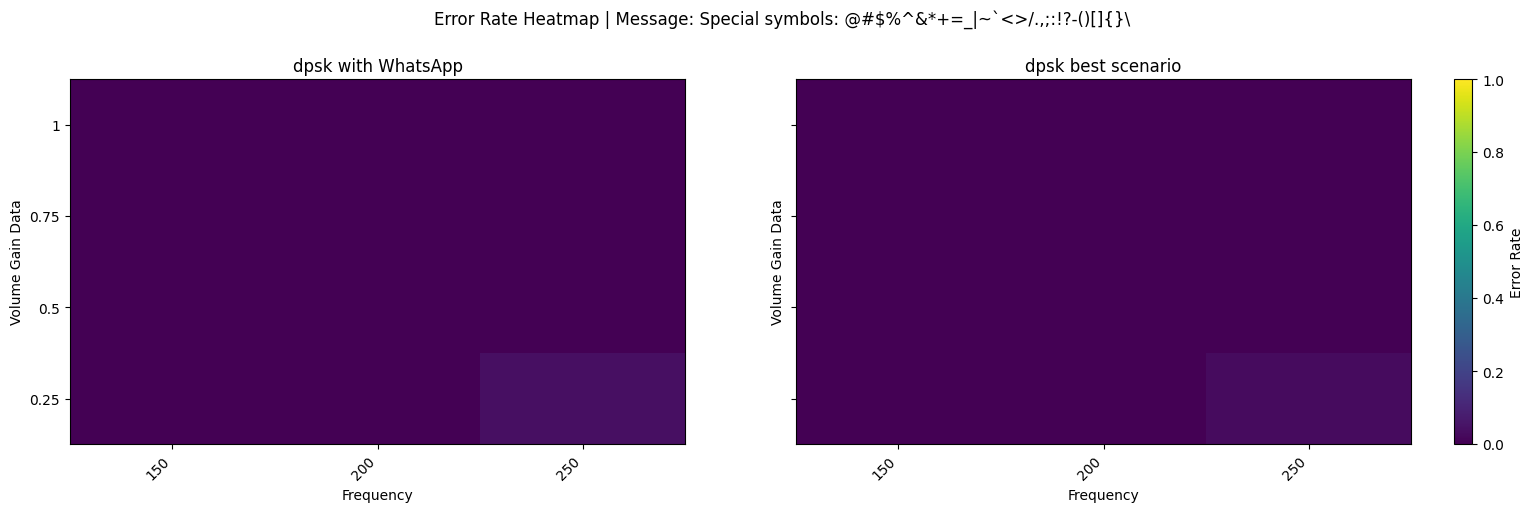

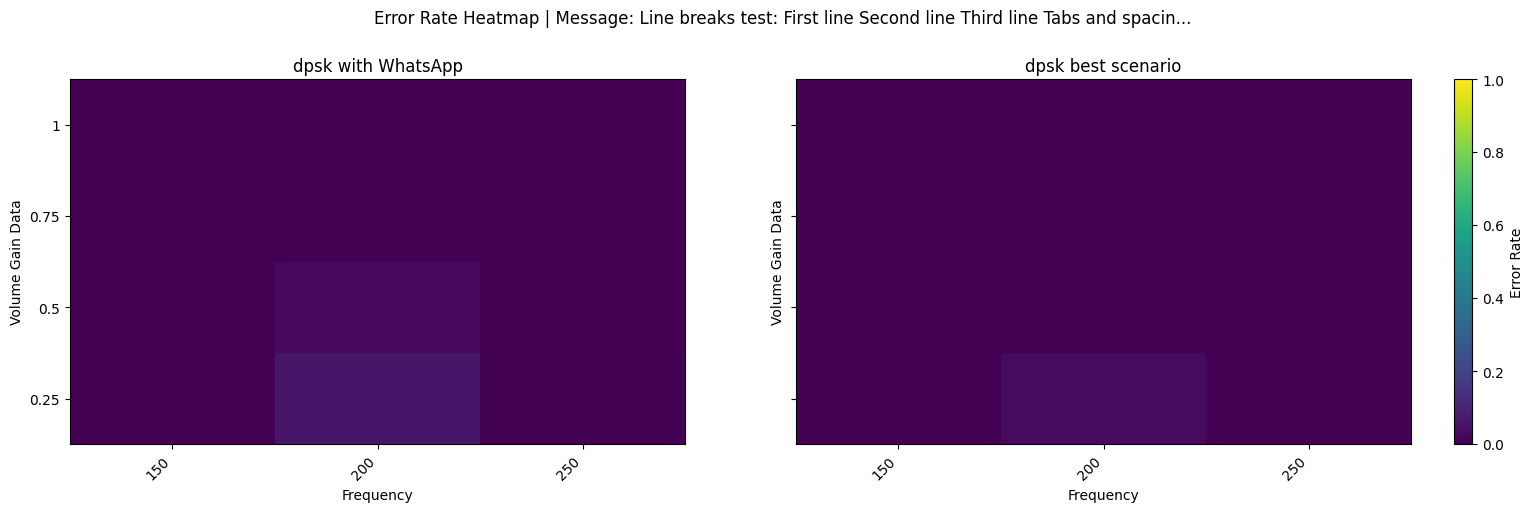

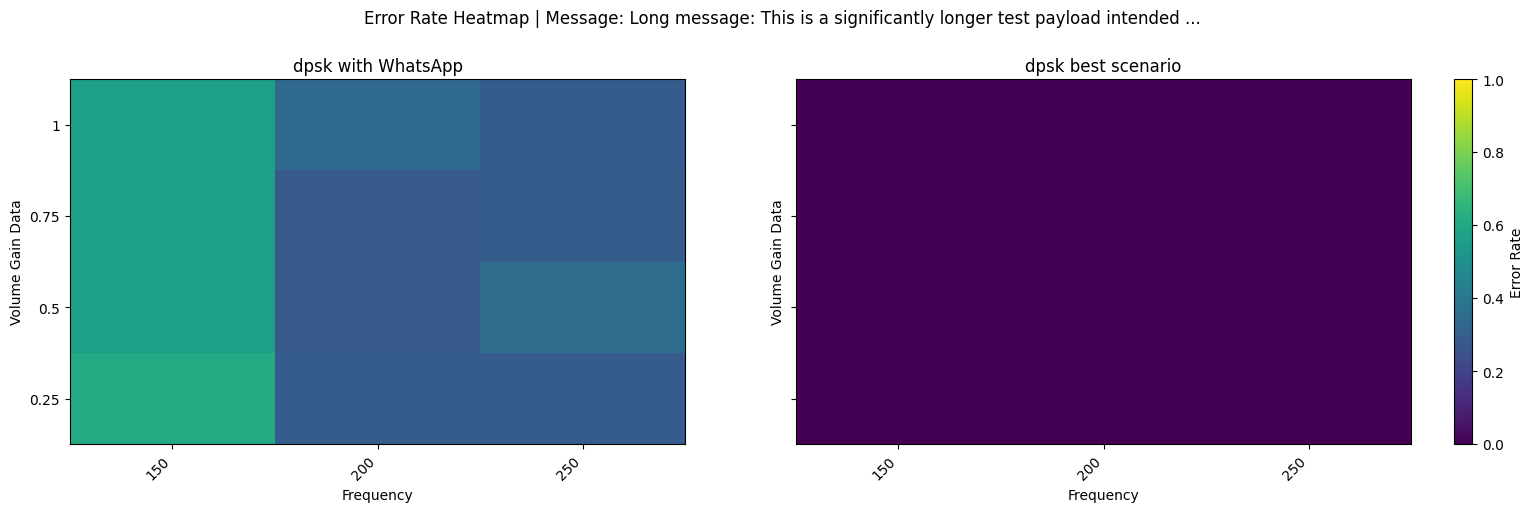

In [24]:
from plot_helpers import plot_error_rate_heatmaps_by_message_comparison

plot_error_rate_heatmaps_by_message_comparison(
    df_first_average,
    df_second_average,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
)

## Error Rate vs Frequency (Comparison per Message)
Each figure is split into two columns for direct comparison between actual and best-case runs.

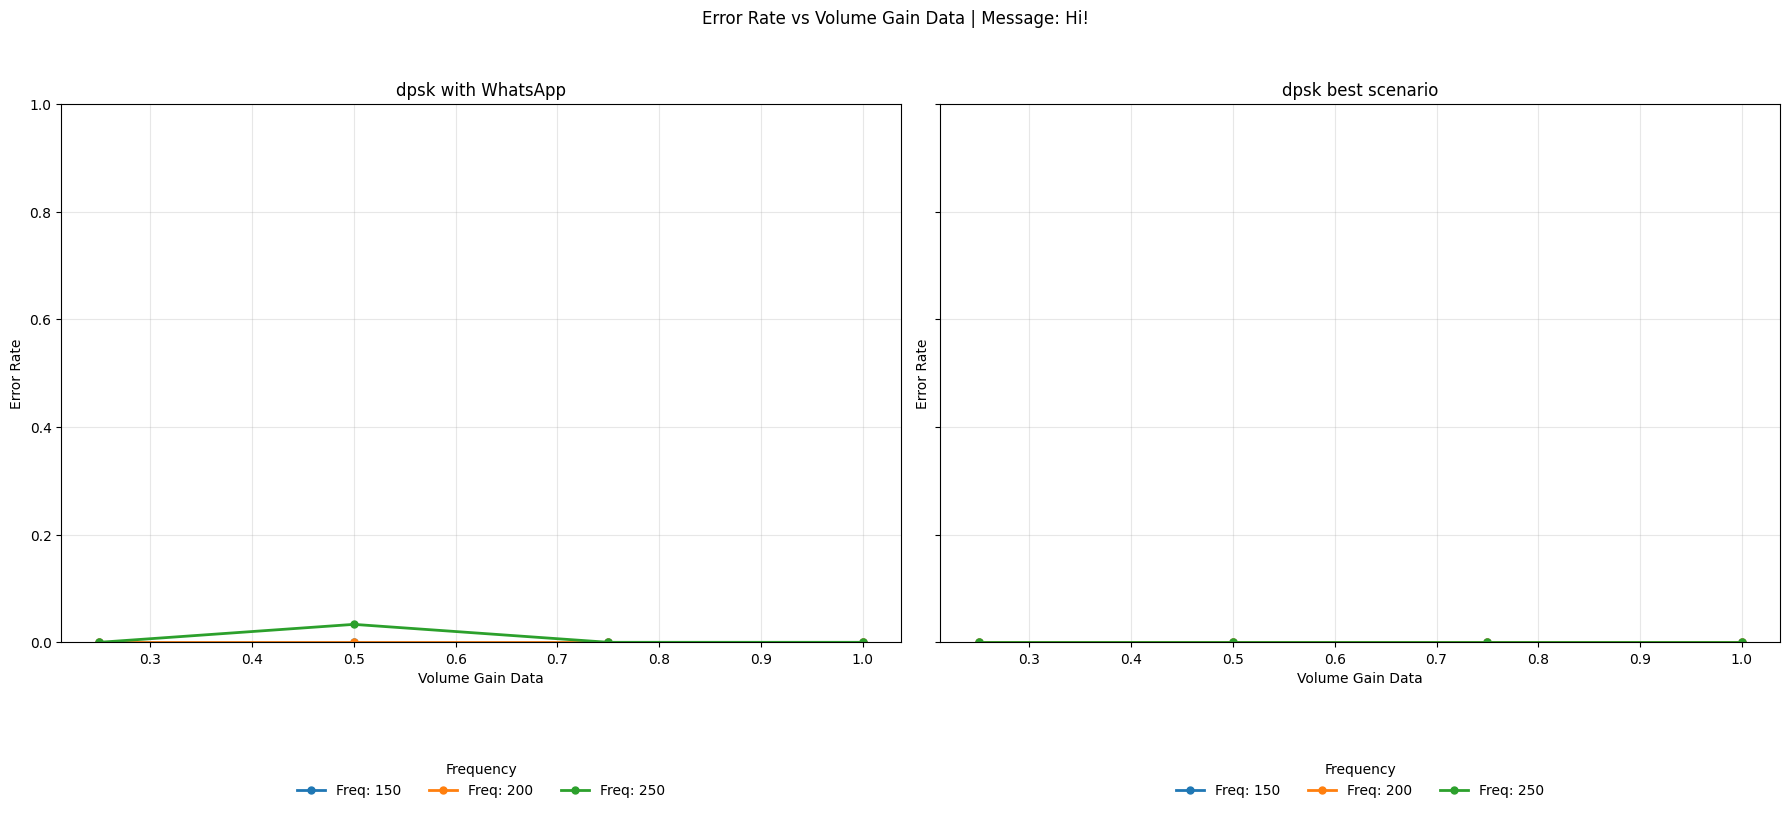

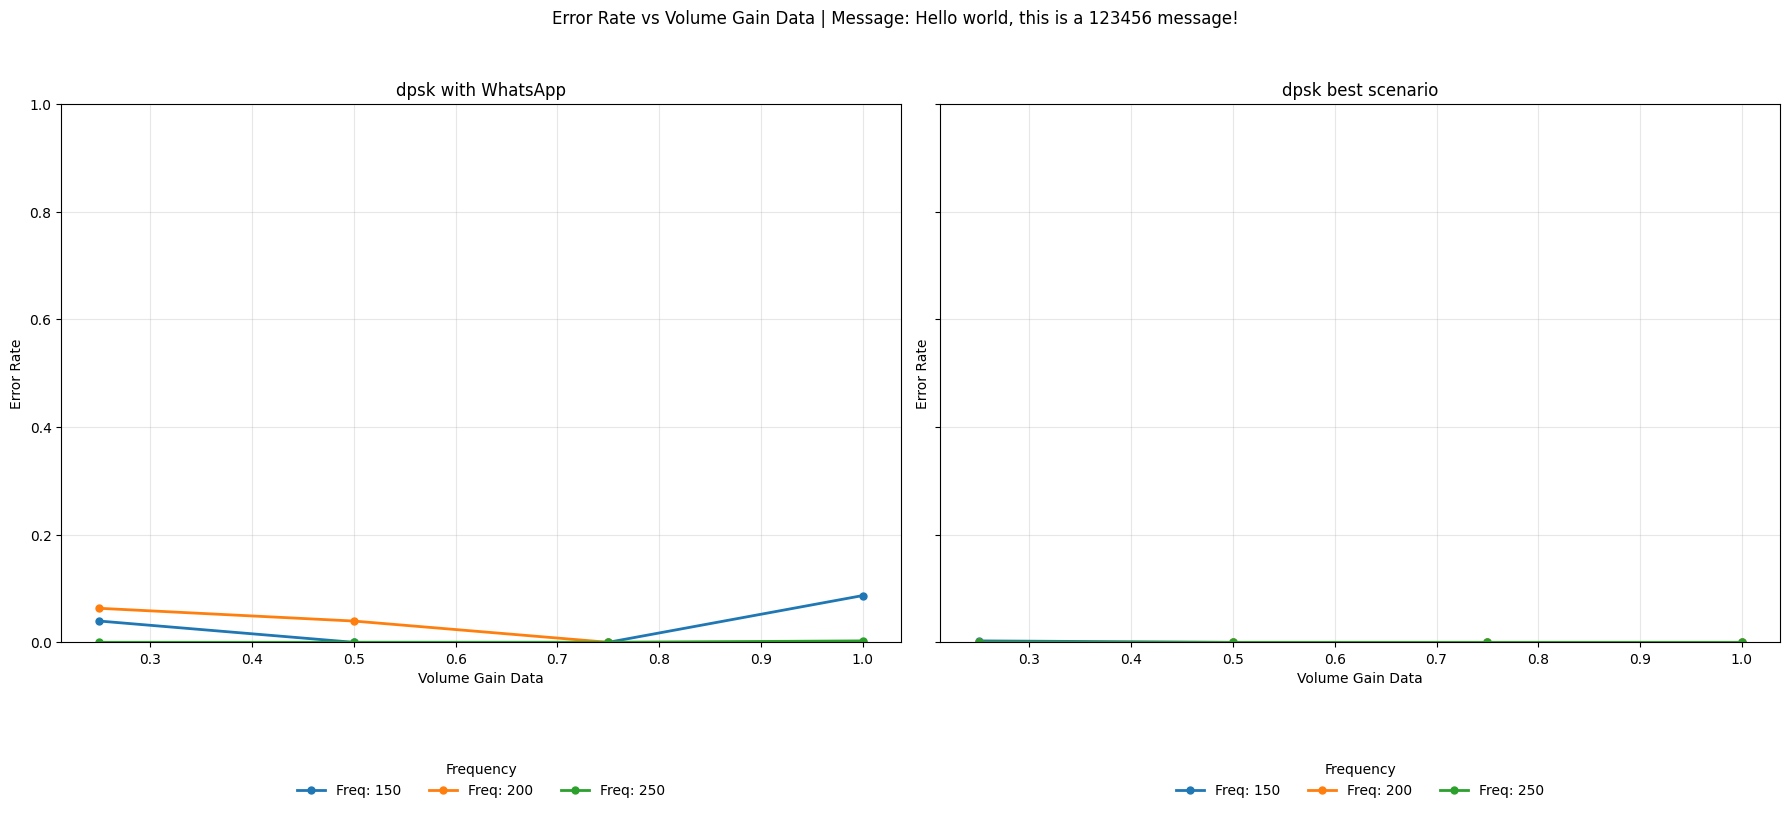

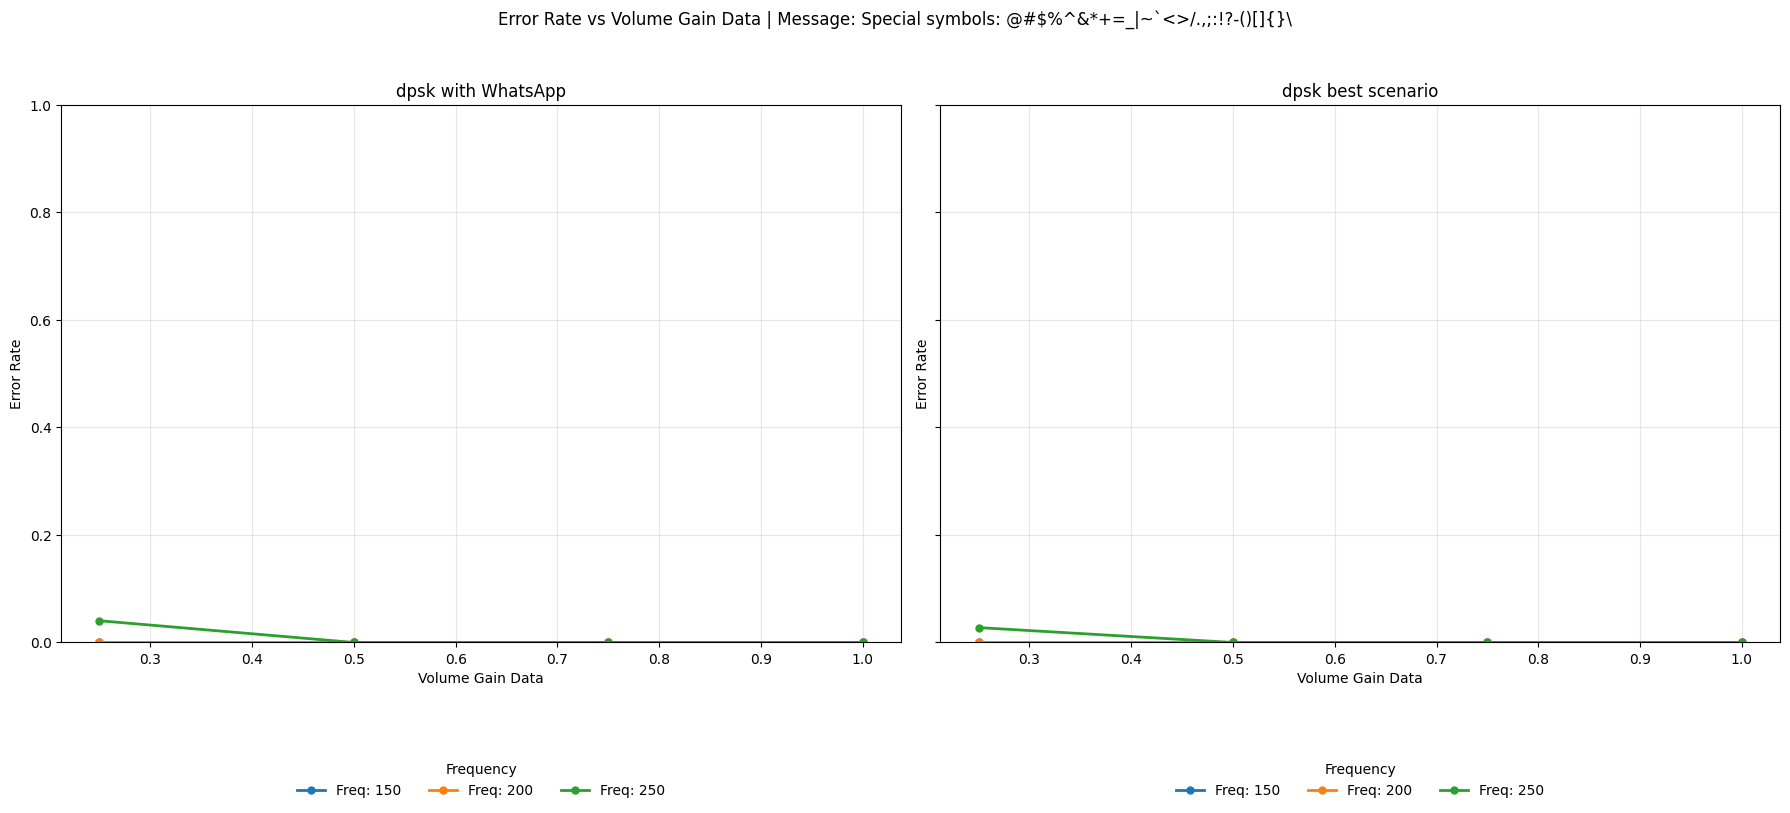

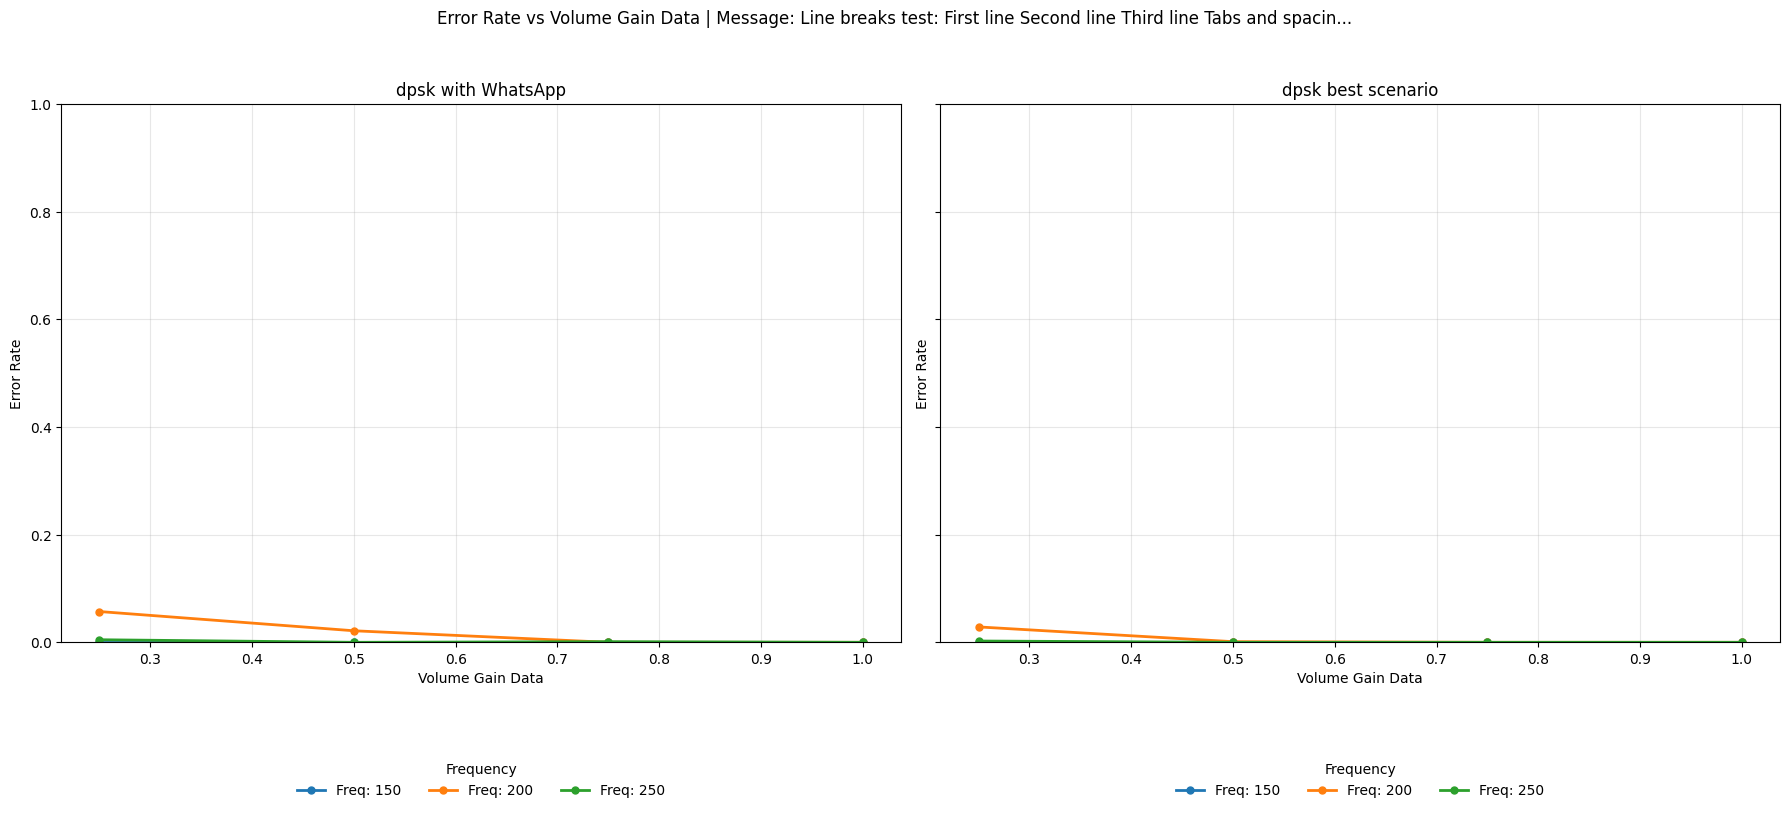

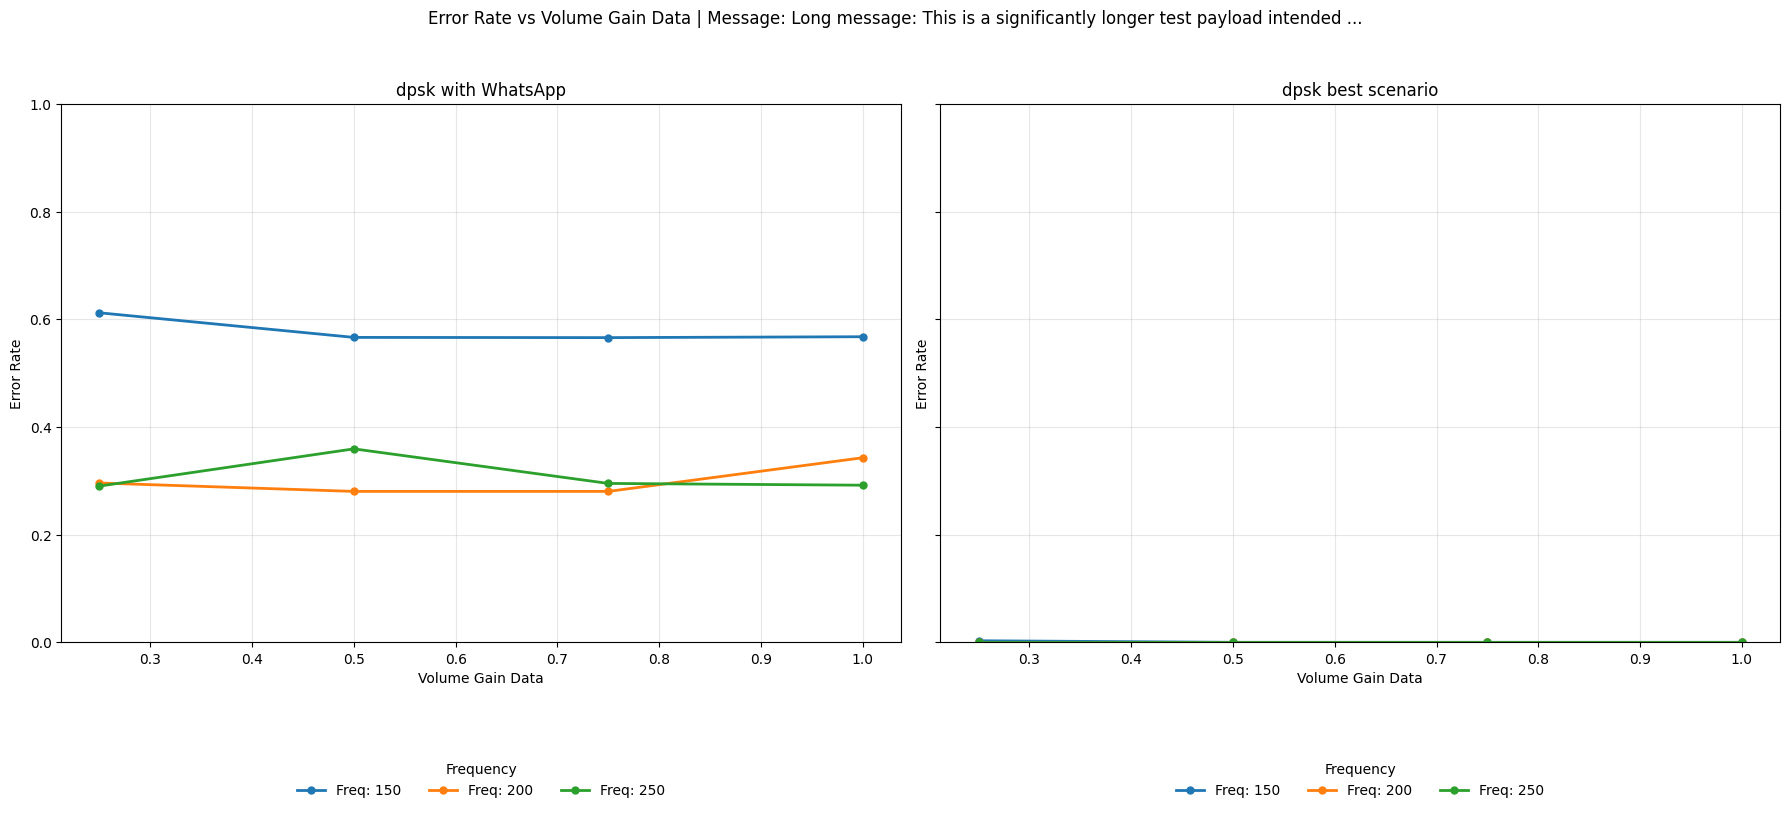

In [25]:
from plot_helpers import plot_error_rate_vs_frequency_by_message_comparison

plot_error_rate_vs_frequency_by_message_comparison(
    df_first_average,
    df_second_average,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
)

## Error Rate Variance by Frequency (All Volume Gain Data Values, Comparison)
This section generates one comparison figure per available `volume_gain_data` value.
Each figure has:
- Column A: `csv_path`
- Column B: `no_audio_compression`
Violin plots are used by default and automatically fall back to box plots when groups are sparse.

Generating 4 comparison plots (one per volume_gain_data).


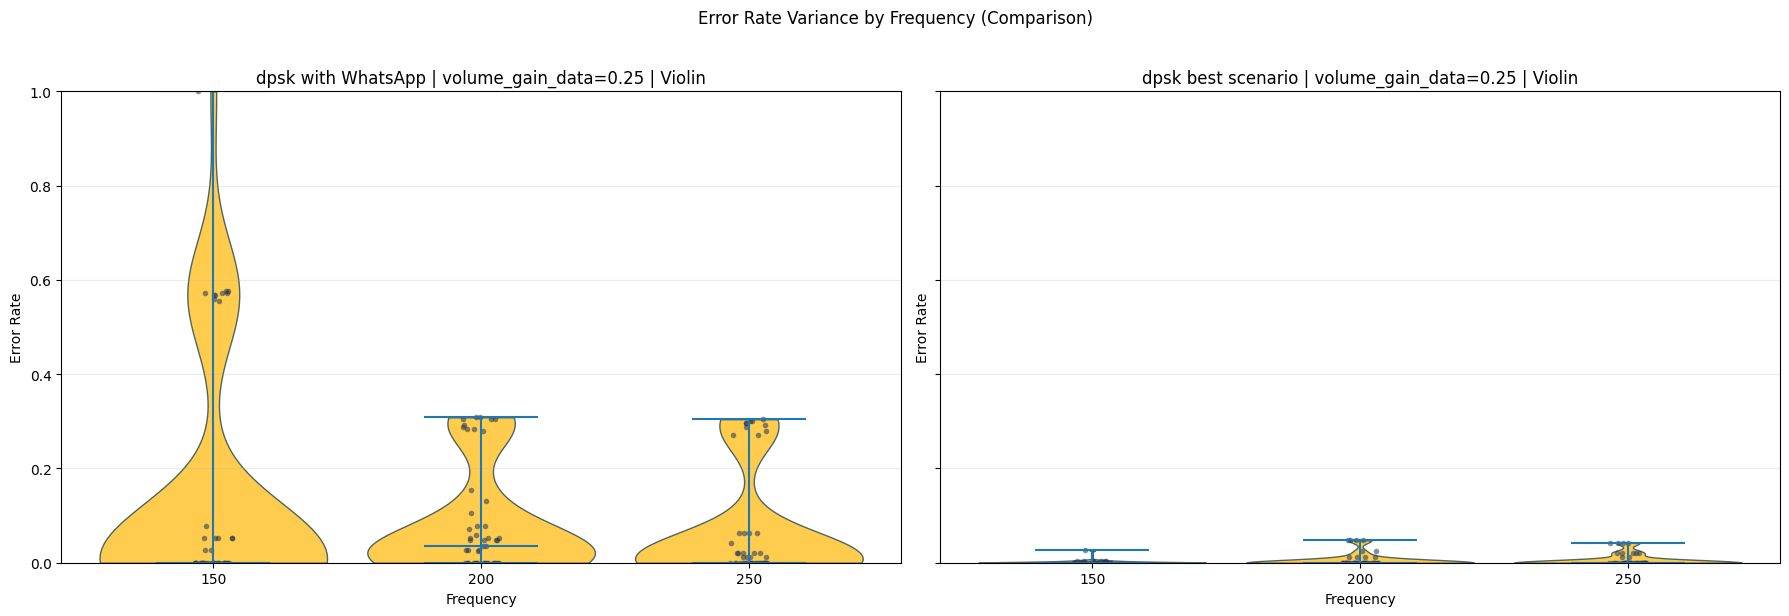

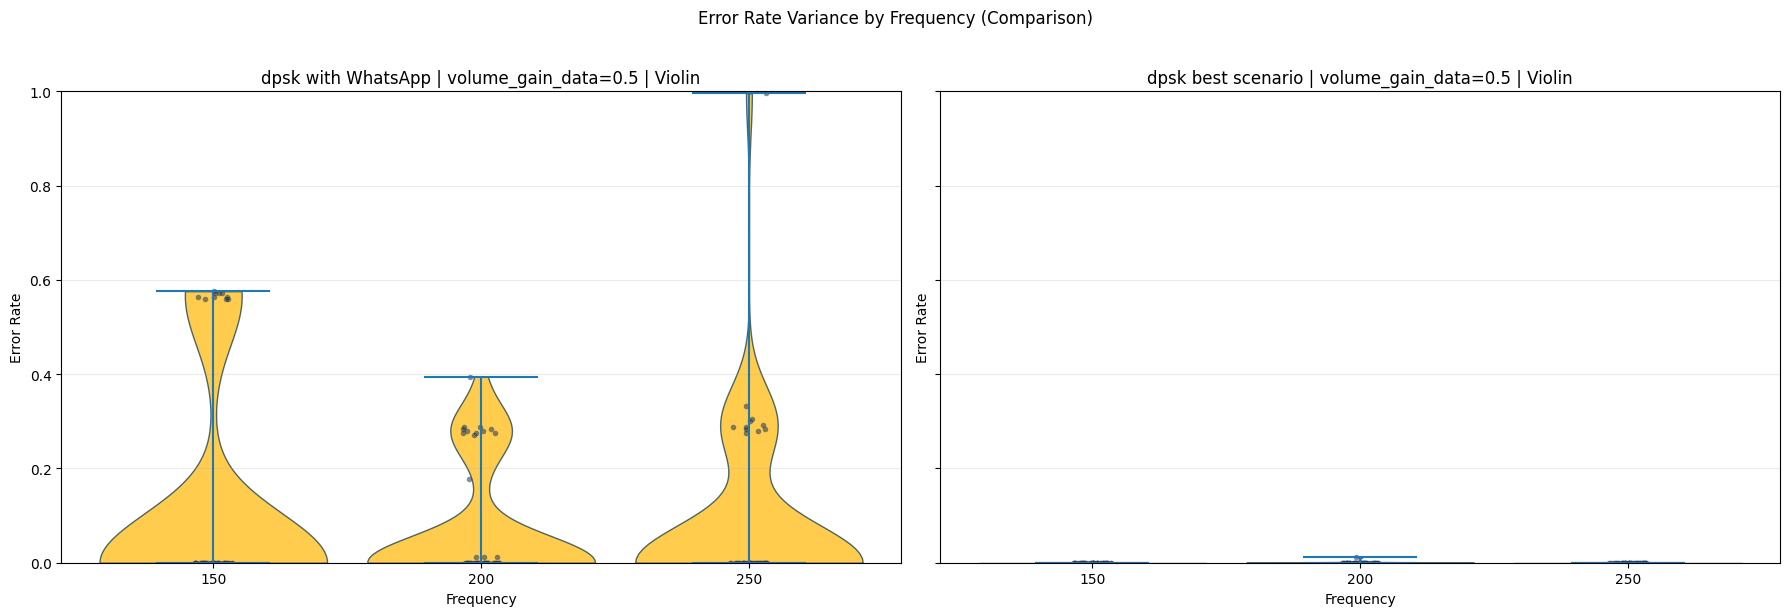

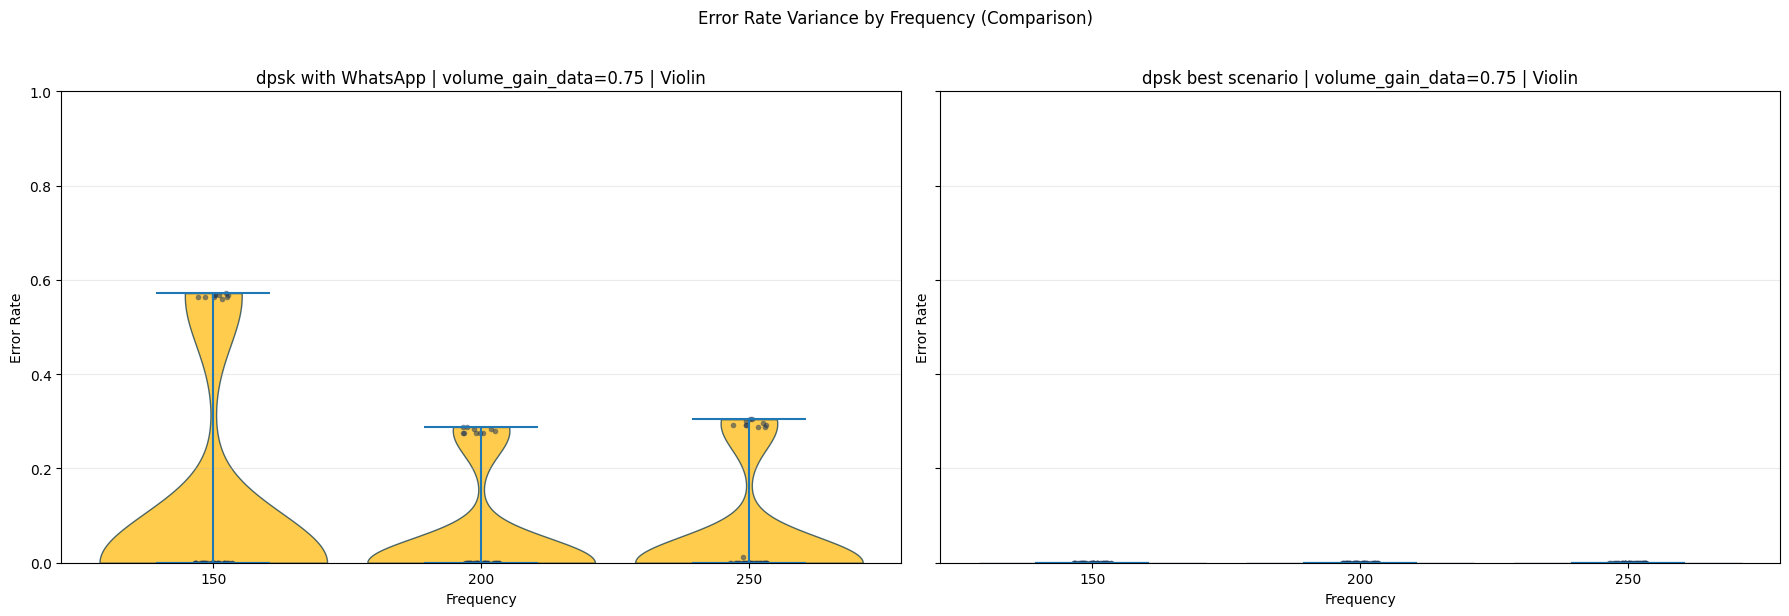

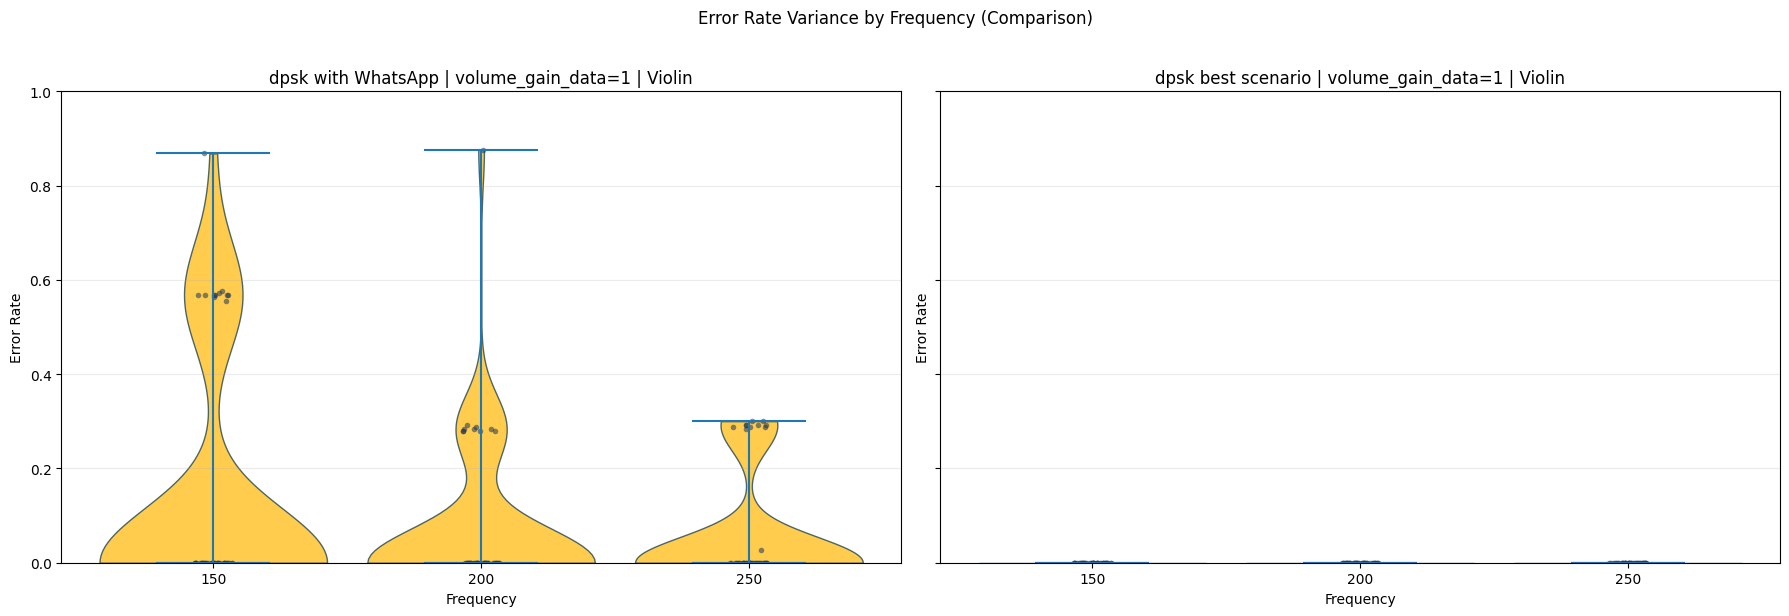

In [26]:
from plot_helpers import plot_error_rate_variance_for_all_volume_gains_comparison

plot_error_rate_variance_for_all_volume_gains_comparison(
    df_first,
    df_second,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
    prefer_box_if_sparse=True,
    min_points_per_group=5,
)

## 3D Static Render (Non-interactive)
This adds a static 3D view of the same comparison data without changing the interactive Plotly figure above.

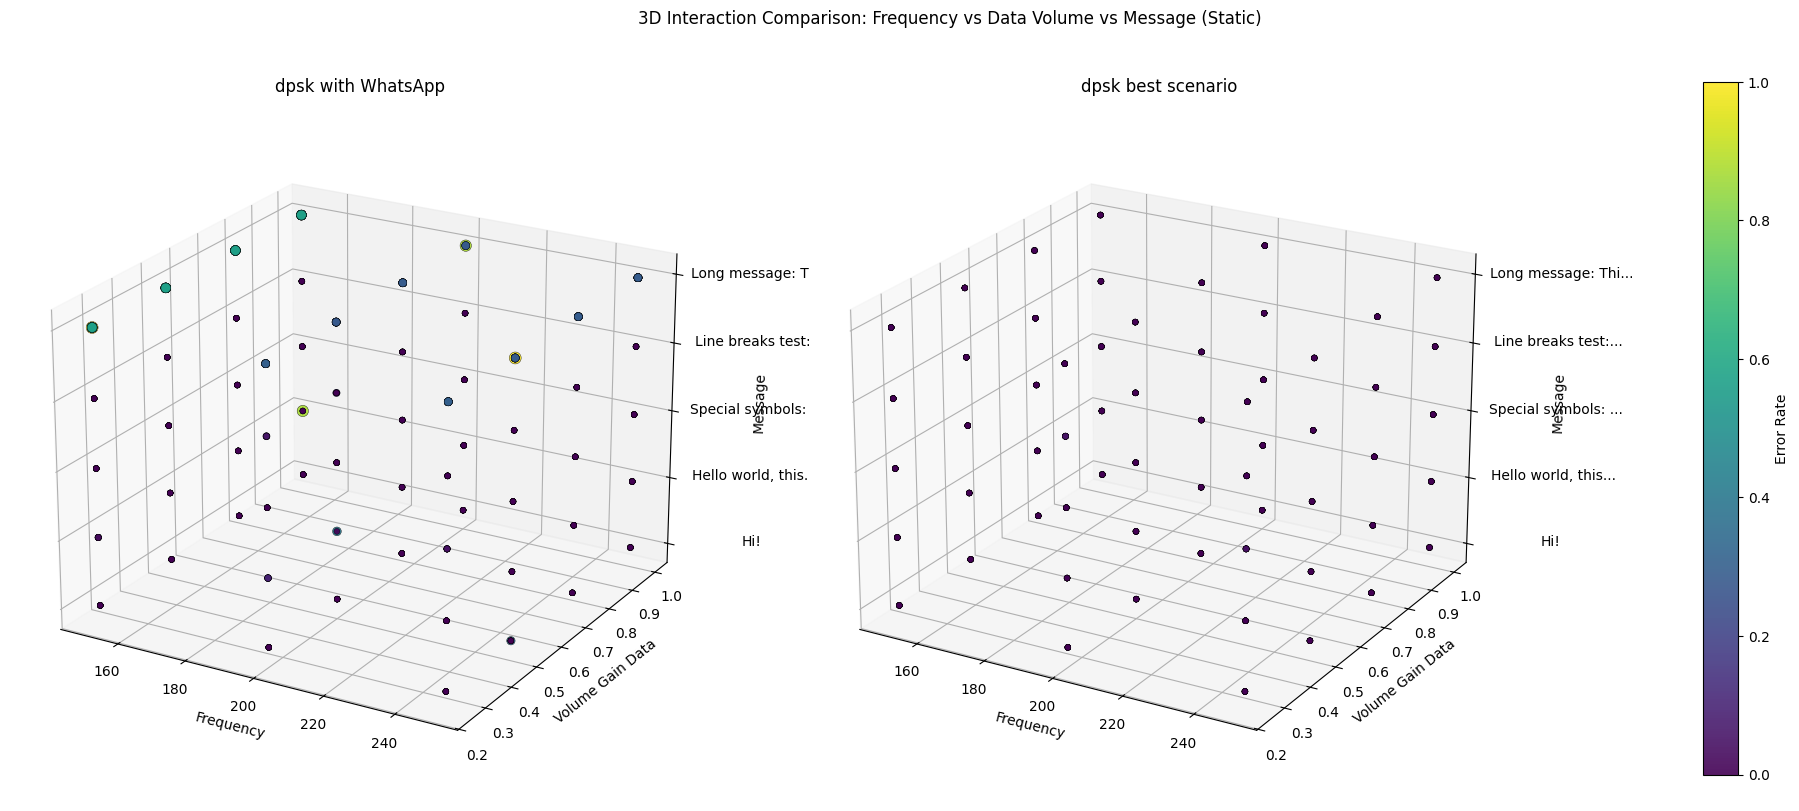

In [27]:
from plot_helpers import plot_static_3d_interaction_comparison

plot_static_3d_interaction_comparison(
    df_first,
    df_second,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
)

## 3D Interaction: Frequency, Data Volume, and Message (Comparison)
This figure is split into two 3D panels:
- Column A: `csv_path` (actual pipeline output)
- Column B: `no_audio_compression` (best-case reference)
Color and marker size encode `error_rate` (lower is better).

In [28]:
from plot_helpers import plot_3d_interaction_comparison

plot_3d_interaction_comparison(
    df_first,
    df_second,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
)